In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, StringType, LongType
)
import time

spark = SparkSession.builder \
    .master("spark://group13-master:7077") \
    .appName("test") \
    .config("spark.dynamicAllocation.enabled", "true") \
    .config("spark.shuffle.service.enabled", "false") \
    .config("spark.dynamicAllocation.shuffleTracking.enabled", "true") \
    .enableHiveSupport() \
    .getOrCreate()

reddit_schema = StructType([
    StructField("author", StringType(), True),
    StructField("body", StringType(), True),
    StructField("normalizedBody", StringType(), True),
    StructField("content", StringType(), True),
    StructField("content_len", LongType(), True),
    StructField("summary", StringType(), True),
    StructField("summary_len", LongType(), True),
    StructField("id", StringType(), True),
    StructField("subreddit", StringType(), True),
    StructField("subreddit_id", StringType(), True),
    StructField("title", StringType(), True)
])

path = "hdfs://group13-master:9000/project/reddit/raw"
#parquet_path = "hdfs://group13-master:9000/project/reddit/parquet/raw"
parquet_path = "hdfs:///project/reddit/parquet"

df = spark.read.schema(reddit_schema).json(path)
df.show(5)

26/03/09 15:35:07 WARN StandaloneSchedulerBackend: Dynamic allocation enabled without spark.executor.cores explicitly set, you may get more executors allocated than expected. It's recommended to set spark.executor.cores explicitly. Please check SPARK-30299 for more details.
[Stage 0:>                                                          (0 + 1) / 1]

+----------------+--------------------+--------------------+--------------------+-----------+--------------------+-----------+-------+-----------+------------+--------+
|          author|                body|      normalizedBody|             content|content_len|             summary|summary_len|     id|  subreddit|subreddit_id|   title|
+----------------+--------------------+--------------------+--------------------+-----------+--------------------+-----------+-------+-----------+------------+--------+
|raysofdarkmatter|I think it should...|I think it should...|I think it should...|        178|Shifting seasonal...|          8|c69al3r|       math|    t5_2qh0n|    NULL|
|         Stork13|Art is about the ...|Art is about the ...|Art is about the ...|        148|Personal opinions...|          4|c6a9nxd|      funny|    t5_2qh33|    NULL|
|   Cloud_dreamer|Ask me what I thi...|Ask me what I thi...|Ask me what I thi...|         76|insults and slack...|         73|c6acx4l|Borderlands|    t5_2r

In [8]:
#df.write.mode("overwrite").bucketBy(40, "author").sortBy("subreddit").option("compression", "snappy").parquet("hdfs:///project/reddit/parquet")
#df.write.mode("overwrite").bucketBy(40, "author").sortBy("subreddit").option("compression", "snappy").saveAsTable("parquet")

# Only used once to convert
# df.write.mode("overwrite").option("compression", "snappy").parquet(parquet_path)

In [9]:
#df_parquet = spark.table("parquet")
df_parquet = spark.read.parquet(parquet_path)

In [10]:
from pyspark.sql.functions import col



# Keeep neccesary columns
clean_df = df_parquet.select("author", "subreddit") \
    .filter(col("author").isNotNull()) \
    .filter(col("subreddit").isNotNull()) \
    .filter(col("author") != "[deleted]")

clean_df.show(5, truncate=False)

[Stage 3:>                                                          (0 + 1) / 1]

+-----------+---------+
|author     |subreddit|
+-----------+---------+
|analog_jedi|swtor    |
|DuckSwapper|aww      |
|JoeyTBND   |dayz     |
|PseudoTebow|AskMen   |
|foxy1167   |nuzlocke |
+-----------+---------+
only showing top 5 rows



In [12]:
target_subreddit = "AskReddit"
print("Target subreddit:", target_subreddit)

Target subreddit: AskReddit


In [13]:
#Active users
from pyspark.sql.functions import lower, count, desc

users = clean_df.filter(col("subreddit") == target_subreddit) \
                .select("author") \
                .distinct()

print("Users in subreddit:", users.count())

user_posts = clean_df.join(users, "author")

print("Total posts by these users:", user_posts.count())

other_posts = user_posts.filter(col("subreddit") != target_subreddit)

print("Posts in other subreddits:", other_posts.count())

Users in subreddit: 275849


[Stage 14:======================================>                   (4 + 2) / 6]

Total posts by these users: 1004676


[Stage 23:================================================>         (5 + 1) / 6]

Posts in other subreddits: 534093


In [ ]:
clean_df.cache()
clean_df.count()

In [15]:
top_subreddits = clean_df.groupBy("subreddit") \
                         .count() \
                         .orderBy("count", ascending=False)

top_subreddits.show(20)

[Stage 28:=======================================================>(57 + 1) / 58]

+-----------------+------+
|        subreddit| count|
+-----------------+------+
|        AskReddit|470583|
|  leagueoflegends| 49021|
|    AdviceAnimals| 37231|
|            funny| 35197|
|             pics| 32077|
|           gaming| 31574|
|         politics| 30875|
|          atheism| 27274|
|              WTF| 22966|
|    todayilearned| 22593|
|explainlikeimfive| 22535|
|        worldnews| 20705|
|           videos| 18805|
|             IAmA| 18762|
|            trees| 15806|
|            DotA2| 12788|
|       technology| 12233|
|    relationships| 12075|
|          Fitness| 11070|
|             news| 10617|
+-----------------+------+
only showing top 20 rows



In [16]:
from pyspark.sql.functions import countDistinct
related_subreddits = other_posts.groupBy("subreddit") \
                                .agg(countDistinct("author").alias("unique_users")) \
                                .orderBy("unique_users", ascending=False)

related_subreddits.show(20)

[Stage 35:======================================>                   (4 + 2) / 6]

+-------------------+------------+
|          subreddit|unique_users|
+-------------------+------------+
|              funny|       12611|
|      AdviceAnimals|       12091|
|               pics|       11898|
|             gaming|        9040|
|                WTF|        8596|
|      todayilearned|        8213|
|           politics|        8148|
|               IAmA|        7071|
|            atheism|        6870|
|             videos|        6631|
|          worldnews|        5821|
|  explainlikeimfive|        5745|
|         reddit.com|        4131|
|         technology|        3912|
|    leagueoflegends|        3524|
|              trees|        3391|
|               news|        3141|
|            science|        2942|
|fffffffuuuuuuuuuuuu|        2876|
|    TwoXChromosomes|        2711|
+-------------------+------------+
only showing top 20 rows



In [17]:
top10 = related_subreddits.limit(10)
top10.show(truncate=False)

[Stage 44:================================================>         (5 + 1) / 6]

+-------------+------------+
|subreddit    |unique_users|
+-------------+------------+
|funny        |12611       |
|AdviceAnimals|12091       |
|pics         |11898       |
|gaming       |9040        |
|WTF          |8596        |
|todayilearned|8213        |
|politics     |8148        |
|IAmA         |7071        |
|atheism      |6870        |
|videos       |6631        |
+-------------+------------+



In [18]:
top10_pd = top10.toPandas()
top10_pd

,subreddit,unique_users
0,funny,12611
1,AdviceAnimals,12091
2,pics,11898
3,gaming,9040
4,WTF,8596
5,todayilearned,8213
6,politics,8148
7,IAmA,7071
8,atheism,6870
9,videos,6631


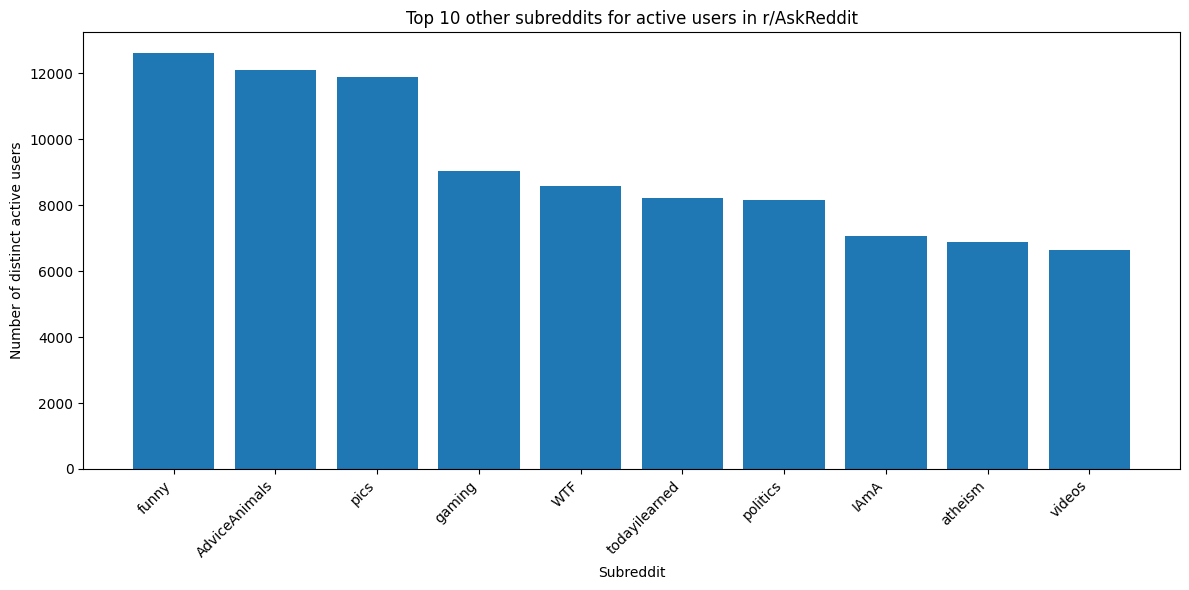

In [19]:
#Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(top10_pd["subreddit"], top10_pd["unique_users"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Subreddit")
plt.ylabel("Number of distinct active users")
plt.title(f"Top 10 other subreddits for active users in r/{target_subreddit}")
plt.tight_layout()
plt.show()

In [20]:
spark.stop()